In [54]:
# Duffing Oscillator Exploration
# =================================
# This notebook compares the dynamics of the Duffing oscillator from periodic to chaotic behaviour.
# Amplitude of the external force (γ) is the control parameter here.

# Author: Riddhika Mahalanabis
# Date: 30.4.2026

In [55]:
import numpy as np
from scipy.integrate import solve_ivp
plt.style.use('seaborn-v0_8-darkgrid')

In [56]:
def duffing(t, y, delta, alpha, beta, gamma, omega):
    x, v = y
    dxdt = v
    dvdt = -delta*v - alpha*x - beta*x**3 + gamma*np.cos(omega*t)
    return [dxdt, dvdt]

def simulate(gamma, t_max=5000, dt=0.01):
    t_eval = np.arange(0, t_max, dt)
    sol = solve_ivp(
        duffing,
        [0, t_max],
        [0.1, 0.0],
        t_eval=t_eval,
        args=(delta, alpha, beta, gamma, omega)
    )
    return sol.t, sol.y[0], sol.y[1]

In [57]:
delta = 0.25
alpha = -1.0
beta  = 1.0
omega = 1.0

gamma_periodic = 0.2
gamma_chaotic  = 0.3

In [58]:
def poincare_section(t, x, v, omega):
    T = 2 * np.pi / omega
    n_points = int(t[-1] / T)

    t_p = np.array([n*T for n in range(n_points)])

    x_p = np.interp(t_p, t, x)
    v_p = np.interp(t_p, t, v)

    # remove transient
    cut = int(0.01 * len(x_p))
    return x_p[cut:], v_p[cut:]

In [59]:
t1, x1, v1 = simulate(gamma_periodic)
t2, x2, v2 = simulate(gamma_chaotic)

xp1, vp1 = poincare_section(t1, x1, v1, omega)
xp2, vp2 = poincare_section(t2, x2, v2, omega)

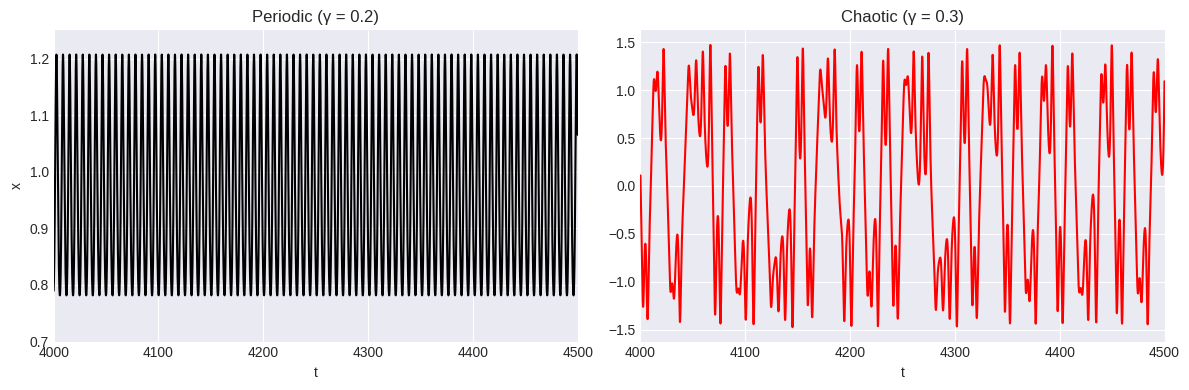

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(t1, x1, 'k')
plt.xlim(4000,4500)
plt.ylim(0.7,1.25)
plt.title("Periodic (γ = 0.2)")
plt.xlabel("t")
plt.ylabel("x")

plt.subplot(1,2,2)
plt.plot(t2, x2, 'r')
plt.xlim(4000,4500)
plt.title("Chaotic (γ = 0.3)")
plt.xlabel("t")

plt.tight_layout()
#plt.savefig("Time_series_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

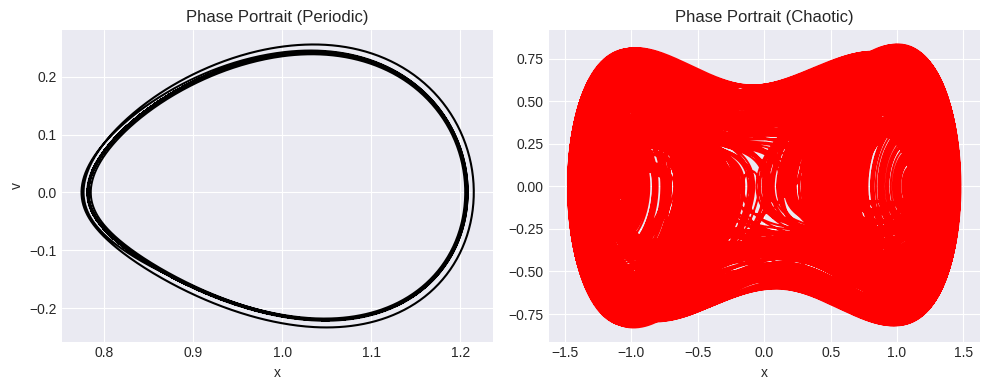

In [61]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(x1[4000:], v1[4000:], 'k')
plt.title("Phase Portrait (Periodic)")
plt.xlabel("x")
plt.ylabel("v")

plt.subplot(1,2,2)
plt.plot(x2[4000:], v2[4000:], 'r')
plt.title("Phase Portrait (Chaotic)")
plt.xlabel("x")

plt.tight_layout()
#plt.savefig("Phase_portrait_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

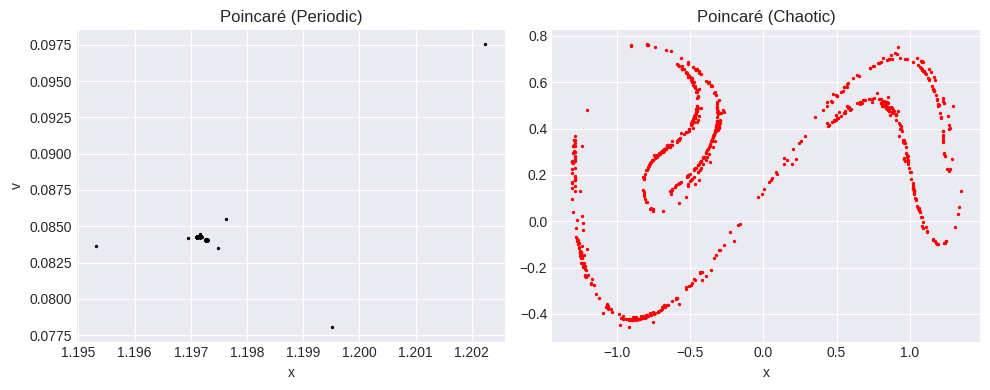

In [62]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(xp1, vp1, color='black', s=2)
plt.title("Poincaré (Periodic)")
plt.xlabel("x")
plt.ylabel("v")

plt.subplot(1,2,2)
plt.scatter(xp2, vp2,  color='red', s=2)
plt.title("Poincaré (Chaotic)")
plt.xlabel("x")

plt.tight_layout()
#plt.savefig("poincare_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# Bifurcation diagram

These plots are used to show the behaviour of a system as one control parameter varies. Can show where the behaviour of the system changes from periodic to chaotic.

Here, weplot the bifuraction diagram using stroboscopic sampling (Poincaré section). This reveals a period-doubling route to chaos.

In [68]:
# Defining control parameter range

gamma_vals = np.linspace(0.2, 0.35, 200)

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [70]:
def bifurcation_diagram(gamma_vals):
    gamma_plot = []
    x_plot = []

    for gamma in tqdm(gamma_vals, desc="Computing bifurcation", total=len(gamma_vals)):
        t, x, v = simulate(gamma)

        # Poincaré section
        xp, vp = poincare_section(t, x, v, omega)

        # Keep last few points
        xp = xp[-50:]

        gamma_plot.extend([gamma]*len(xp))
        x_plot.extend(xp)

    return gamma_plot, x_plot

In [71]:
gamma_plot, x_plot = bifurcation_diagram(gamma_vals)

Computing bifurcation: 100%|██████████| 200/200 [04:30<00:00,  1.35s/it]


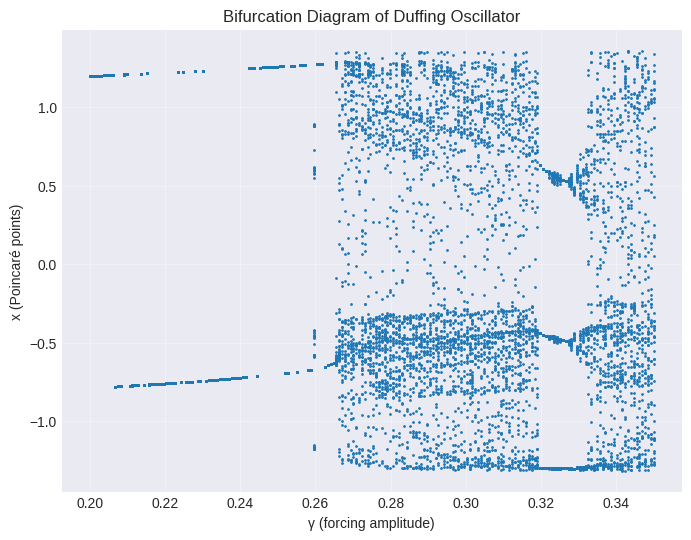

In [72]:
plt.figure(figsize=(8,6))

plt.scatter(gamma_plot, x_plot, s=1)

plt.xlabel("γ (forcing amplitude)")
plt.ylabel("x (Poincaré points)")
plt.title("Bifurcation Diagram of Duffing Oscillator")

plt.grid(alpha=0.3)
plt.savefig("bif_diag_gamma.png", dpi=300, bbox_inches='tight')
plt.show()

## Interpretation

For low forcing amplitudes, the system exhibits periodic motion confined to a single well. As the forcing increases, trajectories explore both wells and eventually become chaotic, as seen from the irregular time series, the double scroll apprearing in the phase portrait and Poincare section. The bifurcation diagram finally shows the behaviour clearly as the control parameter $γ$ is changed slowly. Also windows of periodic behaviour can be seen in the chaotic zone